### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("financial_loan.csv")
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [3]:
df.shape

(38576, 24)

In [4]:
df.drop_duplicates
df.shape

(38576, 24)

In [5]:
df.isna().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [7]:
len(df.columns)

24

#### Removing Irrelevant columns

In [36]:
cols_to_drop = [
    'id', 
    'member_id', 
    'emp_title', 
    'next_payment_date', 
    'issue_date', 
    'last_payment_date', 
    'last_credit_pull_date', 
    'verification_status', 
    'int_rate', 
    'sub_grade',
    'application_type',
    'address_state',
    'total_payment',
    'dti'
]


df2 = df.drop(columns=cols_to_drop, axis = 1)
df2.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount,total_acc
0,< 1 year,C,RENT,Charged Off,car,60 months,30000.0,59.83,2500,4
1,9 years,E,RENT,Fully Paid,car,36 months,48000.0,109.43,3000,4
2,4 years,C,RENT,Charged Off,car,36 months,50000.0,421.65,12000,11
3,< 1 year,B,MORTGAGE,Fully Paid,car,60 months,42000.0,97.06,4500,9
4,10+ years,A,MORTGAGE,Fully Paid,car,36 months,83000.0,106.53,3500,28


In [37]:
df2.describe(include='all')

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount,total_acc
count,38576,38576,38576,38576,38576,38576,3.857600e+04,38576.000000,38576.000000,38576.000000
unique,11,7,5,3,14,2,NaN,NaN,NaN,NaN
top,10+ years,B,RENT,Fully Paid,Debt consolidation,36 months,NaN,NaN,NaN,NaN
freq,8870,11674,18439,32145,18214,28237,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,6.964454e+04,326.862965,11296.066855,22.132544
std,NaN,NaN,NaN,NaN,NaN,NaN,6.429368e+04,209.092000,7460.746022,11.392282
min,NaN,NaN,NaN,NaN,NaN,NaN,4.000000e+03,15.690000,500.000000,2.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,4.150000e+04,168.450000,5500.000000,14.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,6.000000e+04,283.045000,10000.000000,20.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,8.320050e+04,434.442500,15000.000000,29.000000


#### Checking relevance of the Total acct column

<Figure size 800x600 with 0 Axes>

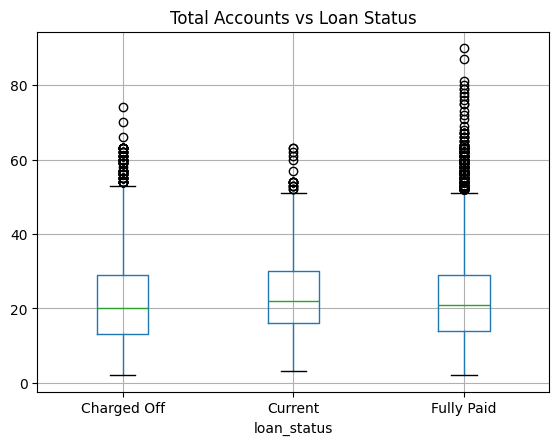

In [38]:
plt.figure(figsize=(8,6))
df2.boxplot(column='total_acc', by='loan_status')
plt.title("Total Accounts vs Loan Status")
plt.suptitle("")  # Remove default "Boxplot grouped by" title
plt.show()

In [39]:
df2 = df2.drop('total_acc', axis=1)
df2.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,Charged Off,car,60 months,30000.0,59.83,2500
1,9 years,E,RENT,Fully Paid,car,36 months,48000.0,109.43,3000
2,4 years,C,RENT,Charged Off,car,36 months,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,Fully Paid,car,60 months,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,Fully Paid,car,36 months,83000.0,106.53,3500


#### Checking for Duplicate values in columns

In [40]:
for column in df2.columns:
    if column in ['annual_income', 'installment', 'loan_amount', 'dti']:
        continue
    print (column)
    print(pd.unique(df2[column]))
    print()

emp_length
['< 1 year' '9 years' '4 years' '10+ years' '3 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years']

grade
['C' 'E' 'B' 'A' 'D' 'F' 'G']

home_ownership
['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE']

loan_status
['Charged Off' 'Fully Paid' 'Current']

purpose
['car' 'credit card' 'Debt consolidation' 'educational' 'home improvement'
 'house' 'major purchase' 'medical' 'moving' 'other' 'renewable_energy'
 'small business' 'vacation' 'wedding']

term
[' 60 months' ' 36 months']



In [110]:
df3 = df2[df2['loan_status'] != 'Current']
df3.shape


(37478, 9)

In [14]:
df3.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,Charged Off,car,60 months,30000.0,59.83,2500
1,9 years,E,RENT,Fully Paid,car,36 months,48000.0,109.43,3000
2,4 years,C,RENT,Charged Off,car,36 months,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,Fully Paid,car,60 months,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,Fully Paid,car,36 months,83000.0,106.53,3500


C:\Users\OWNER\AppData\Local\Temp\ipykernel_20244\3399264162.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['income_group'] = pd.cut(df3['annual_income'], bins=income_bins, labels=income_labels)


<Figure size 800x600 with 0 Axes>

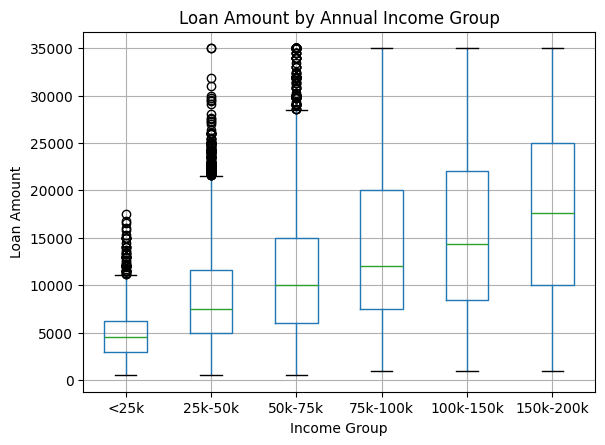

In [118]:


# Create income bins
income_bins = [0, 25000, 50000, 75000, 100000, 150000, 200000]
income_labels = ['<25k','25k-50k','50k-75k','75k-100k','100k-150k','150k-200k']
df3['income_group'] = pd.cut(df3['annual_income'], bins=income_bins, labels=income_labels)

# Boxplot of loan amount per income group
plt.figure(figsize=(8,6))
df3.boxplot(column='loan_amount', by='income_group')
plt.title("Loan Amount by Annual Income Group")
plt.suptitle("")
plt.xlabel("Income Group")
plt.ylabel("Loan Amount")
plt.show()


In [43]:
df3.groupby('loan_status')['loan_amount'].mean()

loan_status
Charged Off    12288.060191
Fully Paid     10930.419972
Name: loan_amount, dtype: float64

In [44]:
df3.groupby(['home_ownership', 'loan_status'])['loan_amount'].mean()

home_ownership  loan_status
MORTGAGE        Charged Off    14230.445988
                Fully Paid     12268.055749
NONE            Fully Paid      5600.000000
OTHER           Charged Off    13747.222222
                Fully Paid      9969.062500
OWN             Charged Off    11450.755668
                Fully Paid     10116.645570
RENT            Charged Off    10789.244511
                Fully Paid      9811.039956
Name: loan_amount, dtype: float64

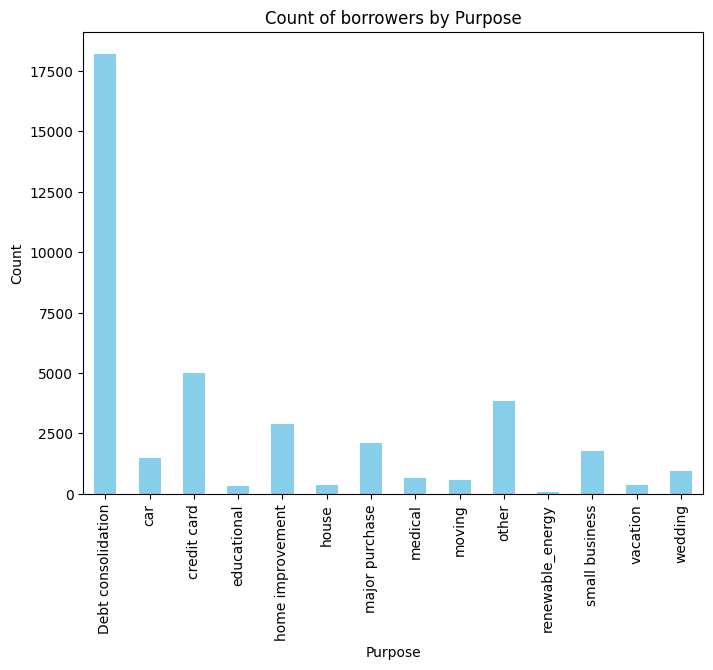

In [45]:
grouped = data = df2.groupby('purpose')['loan_amount'].count()
grouped.plot(kind='bar', figsize=(8,6), color='skyblue')
plt.title("Count of borrowers by Purpose")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.show()


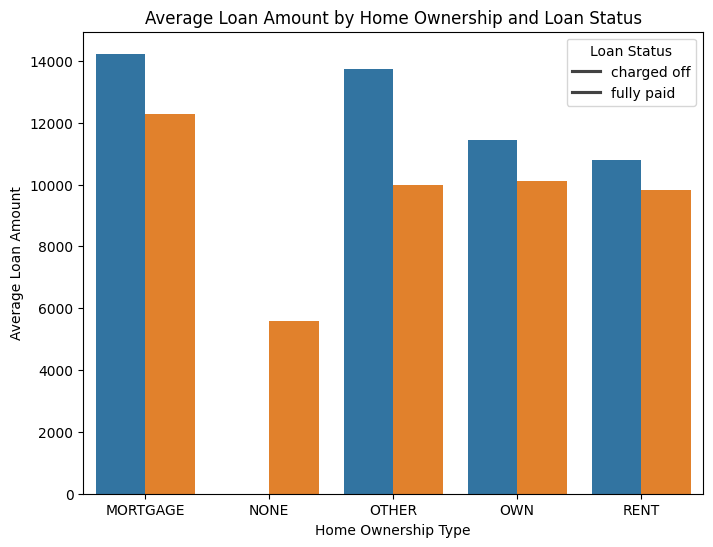

In [46]:
import seaborn as sns


home_loan_means = df3.groupby(['home_ownership', 'loan_status'])['loan_amount'].mean().reset_index()


plt.figure(figsize=(8,6))
sns.barplot(x="home_ownership", y="loan_amount", hue="loan_status", data=home_loan_means )

plt.title("Average Loan Amount by Home Ownership and Loan Status")
plt.xlabel("Home Ownership Type")
plt.ylabel("Average Loan Amount")
plt.legend(title="Loan Status", labels=['charged off', 'fully paid'])
plt.show()

In [47]:
df3.groupby(['grade', 'loan_status'])['loan_amount'].mean()

grade  loan_status
A      Charged Off     8039.402174
       Fully Paid      8727.224786
B      Charged Off    11092.144453
       Fully Paid     11004.708117
C      Charged Off    11184.419431
       Fully Paid     10817.031030
D      Charged Off    12333.535448
       Fully Paid     12158.577298
E      Charged Off    15897.431259
       Fully Paid     15600.039062
F      Charged Off    19300.160772
       Fully Paid     17535.874613
G      Charged Off    18665.561224
       Fully Paid     21125.378788
Name: loan_amount, dtype: float64

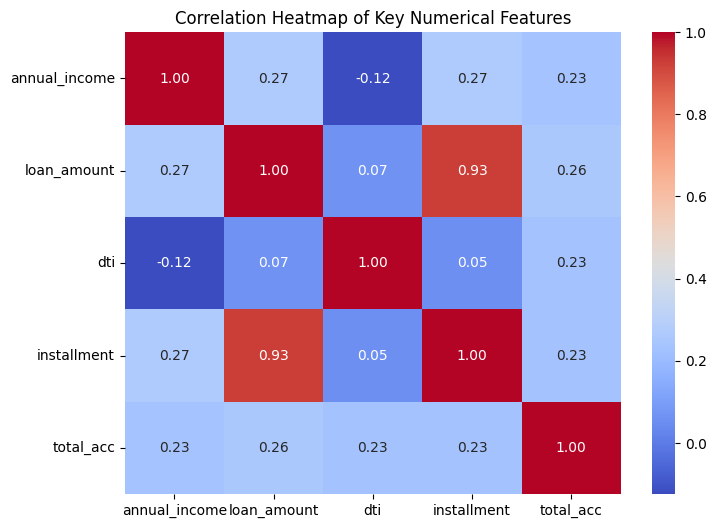

In [111]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['annual_income','loan_amount','dti','installment','total_acc']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()

In [113]:

def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df3 = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    
    return df3

In [114]:
remove_outliers_iqr(df3, ['annual_income', 'installment', 'loan_amount'])

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,Charged Off,car,60 months,30000.0,59.83,2500
1,9 years,E,RENT,Fully Paid,car,36 months,48000.0,109.43,3000
2,4 years,C,RENT,Charged Off,car,36 months,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,Fully Paid,car,60 months,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,Fully Paid,car,36 months,83000.0,106.53,3500
...,...,...,...,...,...,...,...,...,...
38553,4 years,F,RENT,Fully Paid,wedding,60 months,70000.0,436.11,16000
38554,2 years,G,RENT,Fully Paid,wedding,60 months,100000.0,269.70,10000
38555,4 years,G,RENT,Fully Paid,wedding,60 months,85000.0,424.89,16000
38556,10+ years,B,RENT,Fully Paid,wedding,60 months,48000.0,65.97,3000


### DATA PREPROSESSING

In [115]:
df3.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,Charged Off,car,60 months,30000.0,59.83,2500
1,9 years,E,RENT,Fully Paid,car,36 months,48000.0,109.43,3000
2,4 years,C,RENT,Charged Off,car,36 months,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,Fully Paid,car,60 months,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,Fully Paid,car,36 months,83000.0,106.53,3500


In [116]:
df3['loan_status'] = df3['loan_status'].map({'Charged Off' : 0, 'Fully Paid' : 1})

C:\Users\OWNER\AppData\Local\Temp\ipykernel_20244\1428299013.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['loan_status'] = df3['loan_status'].map({'Charged Off' : 0, 'Fully Paid' : 1})


In [119]:
df3 = df3.drop('income_group', axis = 1)

In [54]:
' Emmanuel'.strip()

'Emmanuel'

In [120]:
df3['term'] = df3['term'].str.strip().str[:-7]

In [121]:
df3.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,0,car,60,30000.0,59.83,2500
1,9 years,E,RENT,1,car,36,48000.0,109.43,3000
2,4 years,C,RENT,0,car,36,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,1,car,60,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,1,car,36,83000.0,106.53,3500


In [122]:
X = df3.drop('loan_status', axis=1)
y = df3.loan_status

In [123]:
X.head()

,emp_length,grade,home_ownership,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,car,60,30000.0,59.83,2500
1,9 years,E,RENT,car,36,48000.0,109.43,3000
2,4 years,C,RENT,car,36,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,car,60,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,car,36,83000.0,106.53,3500


In [124]:
dummy_col = ['emp_length',	'grade', 'home_ownership',	'purpose',	'term']
dummies = []
for col in X[dummy_col]:
    dummy = pd.get_dummies(X[col], dtype = int)
    dummies.append(dummy)

In [125]:
X= pd.concat( dummies, axis = 1)
X.head()

,1 year,10+ years,2 years,3 years,4 years,5 years,6 years,7 years,8 years,9 years,...,major purchase,medical,moving,other,renewable_energy,small business,vacation,wedding,36,60
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [126]:
X = pd.concat([X, df3.drop(dummy_col, axis = 1)], axis = 1)
X.head()

,1 year,10+ years,2 years,3 years,4 years,5 years,6 years,7 years,8 years,9 years,...,renewable_energy,small business,vacation,wedding,36,60,loan_status,annual_income,installment,loan_amount
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,30000.0,59.83,2500
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,48000.0,109.43,3000
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,50000.0,421.65,12000
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,42000.0,97.06,4500
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,83000.0,106.53,3500


In [127]:
X = X.drop('loan_status', axis=1)
X.head()

,1 year,10+ years,2 years,3 years,4 years,5 years,6 years,7 years,8 years,9 years,...,other,renewable_energy,small business,vacation,wedding,36,60,annual_income,installment,loan_amount
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,30000.0,59.83,2500
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,48000.0,109.43,3000
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,50000.0,421.65,12000
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,42000.0,97.06,4500
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,83000.0,106.53,3500


In [128]:
y.head()

0    0
1    1
2    0
3    1
4    1
Name: loan_status, dtype: int64

In [129]:
X.shape

(37478, 42)

In [130]:
y.shape

(37478,)

In [131]:
y.value_counts()

loan_status
1    32145
0     5333
Name: count, dtype: int64

### Building a model (ANN) in tensorflow/keras

In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [134]:
y_train.value_counts()

loan_status
1    25696
0     4286
Name: count, dtype: int64

In [83]:
import tensorflow as tf


In [84]:
from tensorflow import losses
from tensorflow import keras
from sklearn.metrics import confusion_matrix , classification_report

In [85]:
X_train.shape

(29982, 42)

In [135]:
model = keras.Sequential([
    keras.layers.Dense(43, input_dim =X_train.shape[1], activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer= 'adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50)

Epoch 1/50


C:\Users\OWNER\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7043 - loss: 871.8236
Epoch 2/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7664 - loss: 22.4906
Epoch 3/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7685 - loss: 16.7483
Epoch 4/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7549 - loss: 21.2363
Epoch 5/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7653 - loss: 16.6695
Epoch 6/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7562 - loss: 15.4647
Epoch 7/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7637 - loss: 13.9180
Epoch 8/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7686 - loss: 14.6187
Epoch 9/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7589 - loss: 18.1522
Epoch 10/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7637 - loss: 15.2038
Epoch 11/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7726 - loss: 15.5913
Epoch 12/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

In [136]:
model.evaluate(X_test, y_test)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8610 - loss: 6.1982


[6.260891437530518, 0.8601921200752258]

In [137]:
y_pred = model.predict(X_test).reshape(-1)
print(y_pred[:10])

# round the values to nearest integer ie 0 or 1
y_pred = np.round(y_pred)
print(y_pred[:10])


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [138]:
y_test[:10]

14327    1
1331     1
21879    0
6701     0
14467    1
13241    0
31440    1
34074    0
20911    1
34575    1
Name: loan_status, dtype: int64

In [139]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report( y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.00      0.01      1047
           1       0.86      1.00      0.92      6449

    accuracy                           0.86      7496
   macro avg       0.64      0.50      0.47      7496
weighted avg       0.80      0.86      0.80      7496



Text(95.72222222222221, 0.5, 'Truth')

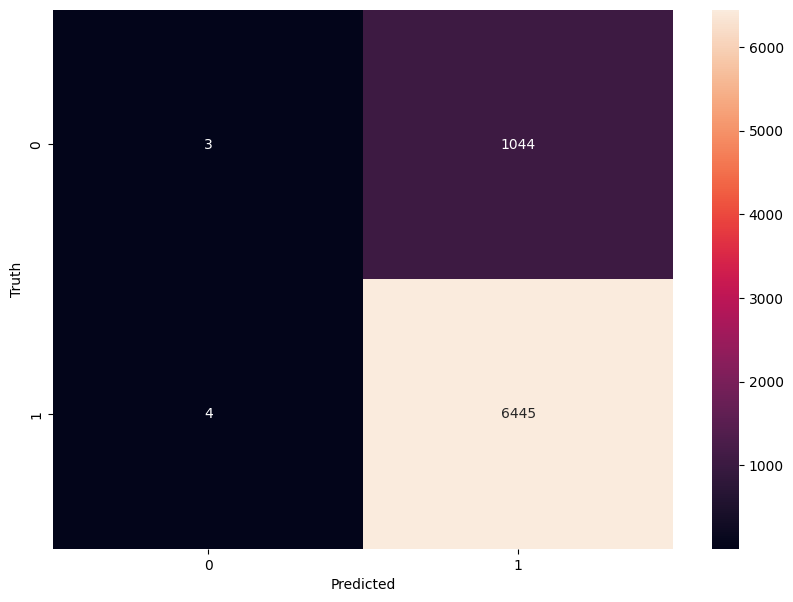

In [140]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

## Mitigating Skewdness of Data using SMOTE (Synthetic Data)

In [141]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

C:\Users\OWNER\anaconda3\envs\tf_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


loan_status
0    32145
1    32145
Name: count, dtype: int64

In [153]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15)

In [143]:
y_test.value_counts()

loan_status
1    6445
0    6413
Name: count, dtype: int64

In [144]:
y_test.shape

(12858,)

In [154]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    keras.layers.Dense(42, input_dim =42,  activation='relu'),
    keras.layers.Dense(21, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer= 'adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])



C:\Users\OWNER\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [155]:
history = model.fit(X_train, y_train, epochs=50)

Epoch 1/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5177 - loss: 237.0405
Epoch 2/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5348 - loss: 36.5638
Epoch 3/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5393 - loss: 37.6057
Epoch 4/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5451 - loss: 47.8953
Epoch 5/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5609 - loss: 25.8810
Epoch 6/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5698 - loss: 25.2595
Epoch 7/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5740 - loss: 21.5901
Epoch 8/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6092 - loss: 15.2327
Epoch 9/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6054 - loss: 20.1994
Epoch 10/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6196 - loss: 13.9182
Epoch 11/50
1608/1608 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6228 - loss: 14.6021
Epoch 12/50
1608/1

In [156]:
model.evaluate(X_test, y_test)

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8973 - loss: 0.2978


[0.29824593663215637, 0.8934515714645386]

In [157]:
y_pred = model.predict(X_test).reshape(-1)
print(y_pred[:10])

# round the values to nearest integer ie 0 or 1
y_pred = np.round(y_pred)
print(y_pred[:10])

402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.7924312  0.08000777 0.05315543 0.7136396  0.02402502 0.182977
 0.60713816 0.46659923 0.03515682 0.7333767 ]
[1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]


In [158]:
y_test[:10]

4423     1
40296    0
45106    0
35759    1
47331    0
63540    0
37386    1
19434    0
61027    0
16812    1
Name: loan_status, dtype: int64

In [159]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report( y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      6413
           1       0.87      0.92      0.90      6445

    accuracy                           0.89     12858
   macro avg       0.89      0.89      0.89     12858
weighted avg       0.89      0.89      0.89     12858



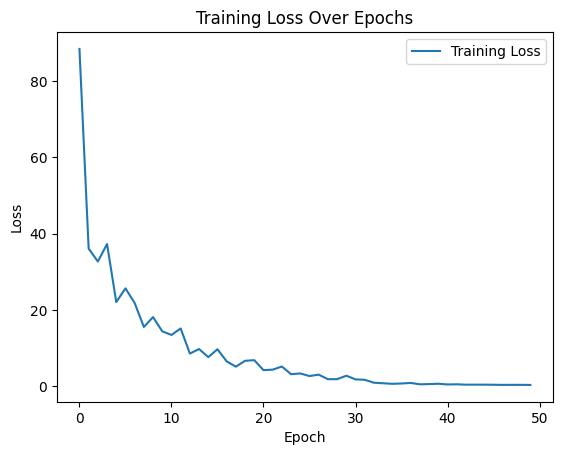

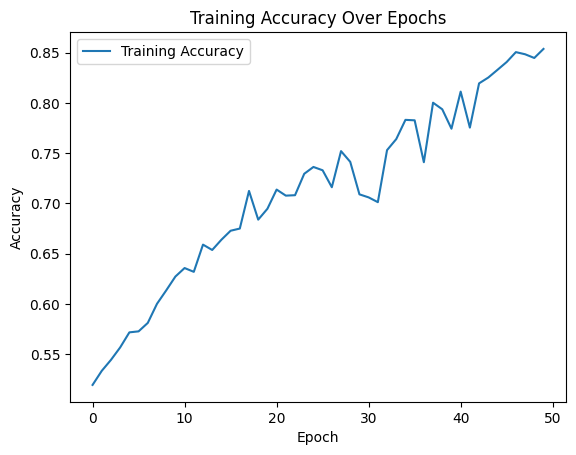

In [160]:


# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.show()


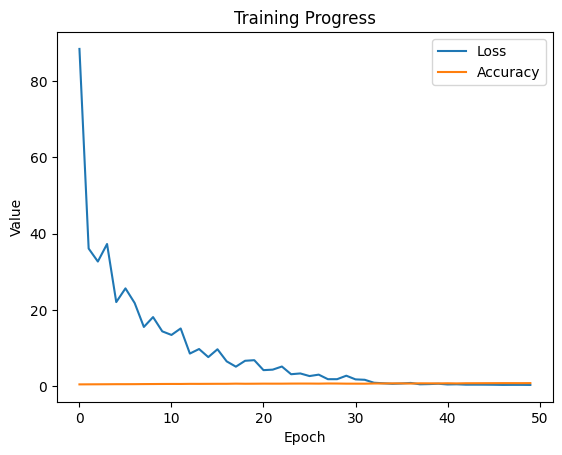

In [161]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Progress')
plt.legend()
plt.show()


Text(95.72222222222221, 0.5, 'Truth')

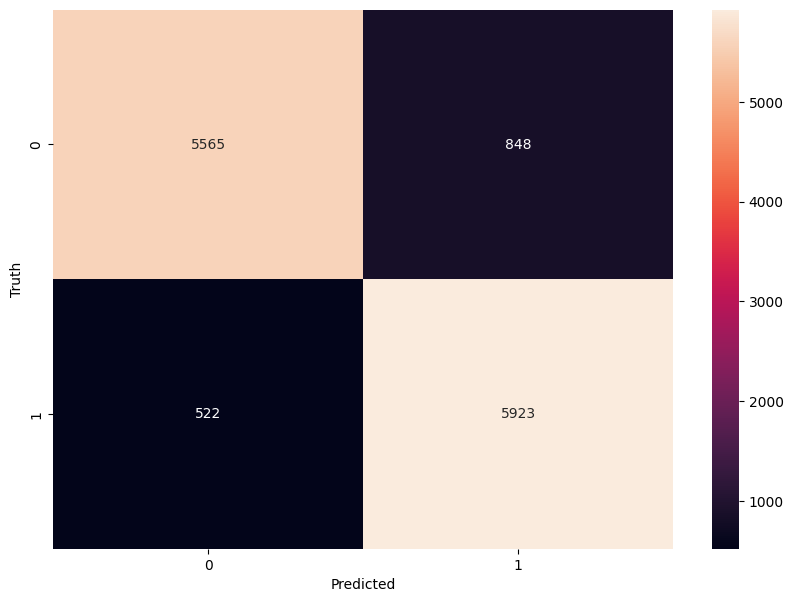

In [162]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [151]:
df3.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,0,car,60,30000.0,59.83,2500
1,9 years,E,RENT,1,car,36,48000.0,109.43,3000
2,4 years,C,RENT,0,car,36,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,1,car,60,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,1,car,36,83000.0,106.53,3500


In [163]:
def predict_decision(emp_length, grade, home_ownership, purpose, term, annual_income, installment, loan_amount):
    import shap
    import pandas as pd
    import numpy as np

   
    X = np.zeros(len(X_sm.columns))

    # Assign numerical values to respective positions
    features = {
        "Emp_length": np.where(X_sm.columns == emp_length)[0][0],
        "Grade": np.where(X_sm.columns == grade)[0][0],
        "Home_ownership": np.where(X_sm.columns == home_ownership)[0][0],
        "Purpose": np.where(X_sm.columns == purpose)[0][0],
        "Term": np.where(X_sm.columns == term)[0][0]
    }

    # Assign numeric (continuous) features
    X[39] = annual_income
    X[40] = installment
    X[41] = loan_amount

    
    for feature, value in features.items():
        if value >= 0:
            X[value] = 1

    
    input_vector = X.reshape(1, -1)

    # Model prediction
    prediction = model.predict(input_vector)[0][0]

    # --- SHAP ---
    explainer = shap.Explainer(model, X_train)  # X_sm is your training data after SMOTE
    shap_values = explainer(input_vector)

   
    shap_df = pd.DataFrame({
        "Feature": X_train.columns,
        "SHAP Value": shap_values.values[0]
    }).sort_values(by="SHAP Value", key=abs, ascending=False)

    # Pick top 4 most influential features
    top_features = shap_df.head(4)

 
    explanations = []
    for _, row in top_features.iterrows():
        influence = "increased" if row["SHAP Value"] > 0 else "reduced"
        explanations.append(f"{row['Feature']} ({influence} approval likelihood)")
    explanation_text = ", ".join(explanations)

    
    return prediction, explanation_text


In [105]:
X_sm.columns

Index(['1 year', '10+ years', '2 years', '3 years', '4 years', '5 years',
       '6 years', '7 years', '8 years', '9 years', '< 1 year', 'A', 'B', 'C',
       'D', 'E', 'F', 'G', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT',
       'Debt consolidation', 'car', 'credit card', 'educational',
       'home improvement', 'house', 'major purchase', 'medical', 'moving',
       'other', 'renewable_energy', 'small business', 'vacation', 'wedding',
       '36', '60', 'annual_income', 'installment', 'loan_amount'],
      dtype='object')

In [166]:
predict_decision('4 years',	'C',	'RENT',	'car',	'36',	50000.0,	421.65,	12000)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


(0.72505915,
 '4 years (increased approval likelihood), car (increased approval likelihood), C (increased approval likelihood), RENT (increased approval likelihood)')

In [167]:
model.save(r"C:\Users\OWNER\Documents\Data Analysis\Tableau\Bankloan Daashboard Files\loan_model.keras")

In [168]:
import json
columns = {
    'data_columns': list(X.columns)
}
with open(r"C:\Users\OWNER\Documents\Data Analysis\Tableau\Bankloan Daashboard Files\data_columns.json", 'w') as f:
    json.dump(columns, f)

In [169]:
df3.head()

,emp_length,grade,home_ownership,loan_status,purpose,term,annual_income,installment,loan_amount
0,< 1 year,C,RENT,0,car,60,30000.0,59.83,2500
1,9 years,E,RENT,1,car,36,48000.0,109.43,3000
2,4 years,C,RENT,0,car,36,50000.0,421.65,12000
3,< 1 year,B,MORTGAGE,1,car,60,42000.0,97.06,4500
4,10+ years,A,MORTGAGE,1,car,36,83000.0,106.53,3500
